## Import Libraries and Initialize
Import essential libraries (pandas, numpy, matplotlib) needed for data manipulation, numerical operations, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Ready to start!")

Ready to start!


## Load Training Data
Define column names for the C-MAPSS dataset (operational settings and sensor measurements) and load the training data from `train_FD001.txt`. Remove extra empty columns and assign proper column names.

In [2]:
# Define the column names for the data
# Based on the C-MAPSS dataset documentation
operational_settings = ['setting_1', 'setting_2', 'setting_3']
sensor_measurements = [f'sensor_{i}' for i in range(1, 22)]
column_names = ['unit_nr', 'time_cycle'] + operational_settings + sensor_measurements

# Load the training data from the text file
# sep=' ' means data is separated by spaces, header=None means there's no header row
train_df = pd.read_csv('./data/train_FD001.txt', sep=' ', header=None)

# The file has extra empty columns at the end, let's drop them
train_df.drop(columns=[26, 27], inplace=True)

# Assign the column names we defined
train_df.columns = column_names

# Show the first 5 rows to verify
train_df.head()

,unit_nr,time_cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## Calculate Remaining Useful Life (RUL)
Calculate the RUL for each engine by finding the maximum cycle per unit and subtracting the current cycle. Clip RUL values at 125 cycles to simplify the prediction problem.

In [3]:
# Find the maximum cycle for each engine unit
max_cycles = train_df.groupby('unit_nr')['time_cycle'].max()

# Merge this max_cycle information back into the original dataframe
train_df = train_df.merge(max_cycles.to_frame(name='max_cycle'), left_on='unit_nr', right_index=True)

# Calculate the RUL for each row
train_df['RUL'] = train_df['max_cycle'] - train_df['time_cycle']

# Drop the 'max_cycle' column as we don't need it anymore
train_df.drop(columns=['max_cycle'], inplace=True)

# --- THIS IS THE CRUCIAL NEW LINE ---
# Clip the RUL at 125 cycles. This simplifies the problem for the model.
train_df['RUL'] = train_df['RUL'].clip(upper=125)


# Show the last 5 rows of engine #1 to see the RUL counting down
print("RUL for the end of Engine 1's life:")
print(train_df[train_df['unit_nr'] == 1].tail())

# Show the first 5 rows of engine #1 to see the clipped RUL
print("\nRUL for the beginning of Engine 1's life:")
print(train_df[train_df['unit_nr'] == 1].head())

RUL for the end of Engine 1's life:
     unit_nr  time_cycle  setting_1  setting_2  setting_3  sensor_1  sensor_2  \
187        1         188    -0.0067     0.0003      100.0    518.67    643.75   
188        1         189    -0.0006     0.0002      100.0    518.67    644.18   
189        1         190    -0.0027     0.0001      100.0    518.67    643.64   
190        1         191    -0.0000    -0.0004      100.0    518.67    643.34   
191        1         192     0.0009    -0.0000      100.0    518.67    643.54   

     sensor_3  sensor_4  sensor_5  ...  sensor_13  sensor_14  sensor_15  \
187   1602.38   1422.78     14.62  ...    2388.23    8117.69     8.5207   
188   1596.17   1428.01     14.62  ...    2388.33    8117.51     8.5183   
189   1599.22   1425.95     14.62  ...    2388.35    8112.58     8.5223   
190   1602.36   1425.77     14.62  ...    2388.30    8114.61     8.5174   
191   1601.41   1427.20     14.62  ...    2388.32    8110.93     8.5113   

     sensor_16  sensor_17 

## Visualize Sensor Trends
Plot sensor measurements (sensors 2, 3, and 11) over time cycles for Engine 1 to understand degradation patterns and identify which sensors show meaningful trends.

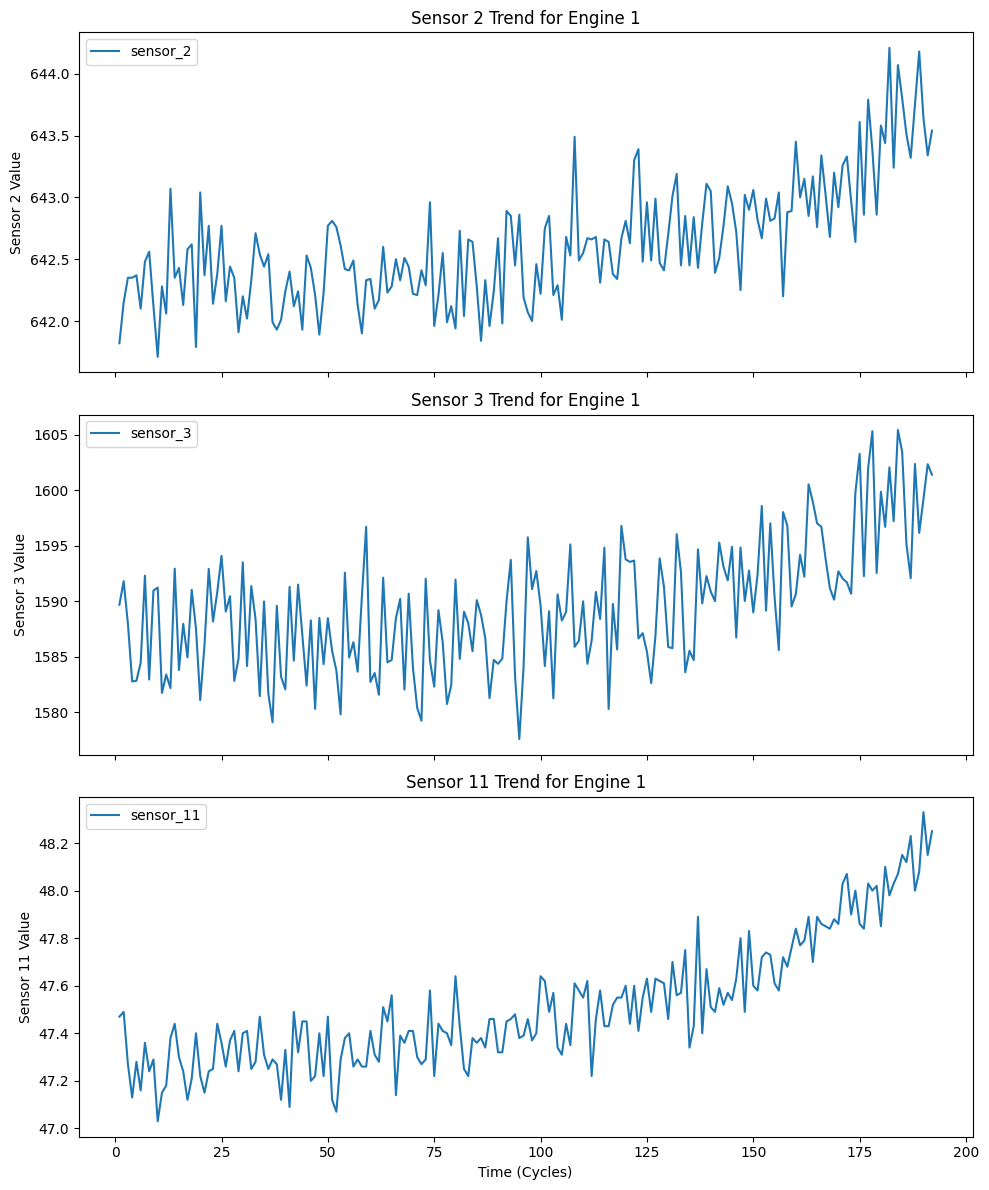

In [4]:
# We'll work with the data for a single engine unit to start
engine_1_df = train_df[train_df['unit_nr'] == 1]

# Plot a few of the sensor measurements over the time cycles
# This helps us see if there is a trend
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Sensor 2
engine_1_df.plot(x='time_cycle', y='sensor_2', ax=axes[0], title='Sensor 2 Trend for Engine 1')
axes[0].set_ylabel('Sensor 2 Value')

# Sensor 3
engine_1_df.plot(x='time_cycle', y='sensor_3', ax=axes[1], title='Sensor 3 Trend for Engine 1')
axes[1].set_ylabel('Sensor 3 Value')

# Sensor 4
engine_1_df.plot(x='time_cycle', y='sensor_11', ax=axes[2], title='Sensor 11 Trend for Engine 1')
axes[2].set_xlabel('Time (Cycles)')
axes[2].set_ylabel('Sensor 11 Value')

plt.tight_layout()
plt.show()

## Remove Constant Sensors
Identify and remove sensors with near-zero variation (constant values) as they don't provide useful information for predicting RUL. Uses standard deviation with a threshold to handle floating-point precision.

In [5]:
print("--- Finding constant sensors (Robust method) ---")

# Let's calculate the standard deviation for each sensor
sensor_std = train_df[sensor_measurements].std()

# Instead of checking for exactly 0, we check for a value smaller than a tiny threshold
# This handles floating point inaccuracies.
threshold = 1e-9 
constant_sensors = sensor_std[sensor_std < threshold].index.tolist()

print(f"\nFound {len(constant_sensors)} sensors with near-zero variation:")
print(constant_sensors)


# --- Now we proceed as before, but with the correctly identified list ---
print("\nDropping these sensors from our data...")
train_df.drop(columns=constant_sensors, inplace=True)

# We also need to remove them from our master list of sensor names
# This is very important for the next steps!
sensor_measurements = [s for s in sensor_measurements if s not in constant_sensors]

print(f"\nSuccess! We now have {len(sensor_measurements)} useful sensors remaining.")
print("The remaining sensors are:", sensor_measurements)

--- Finding constant sensors (Robust method) ---

Found 6 sensors with near-zero variation:
['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

Dropping these sensors from our data...

Success! We now have 15 useful sensors remaining.
The remaining sensors are: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


## Apply Rolling Average Smoothing
Create a smoothed version of sensor data using a rolling window average (window size = 5) to reduce noise and highlight underlying trends. Visualize the difference between original and smoothed data.

C:\Users\HP\AppData\Local\Temp\ipykernel_23332\3826970985.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[f'{sensor_to_smooth}_smoothed'].fillna(method='bfill', inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_23332\3826970985.py:21: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df[f'{sensor_to_smooth}_smoothed'].fillna(method='bfill', inplace=True)


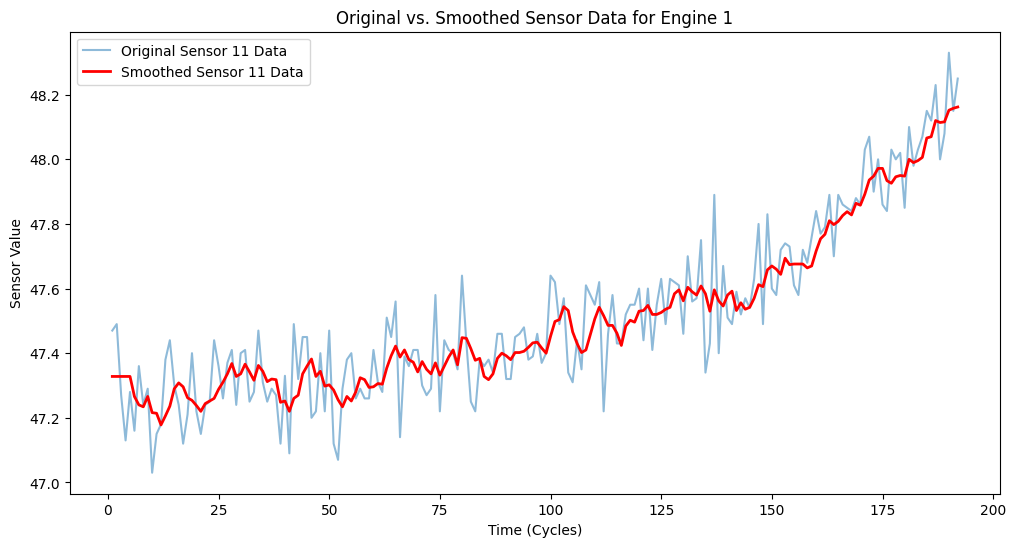

In [6]:
# A window size is the number of past cycles to average over.
# It's a hyperparameter we can tune, but 5 is a good starting point.
window_size = 5

# Let's pick a sensor with a good trend, like sensor 11
sensor_to_smooth = 'sensor_11'

# Calculate the rolling average
# .rolling(window=window_size) creates the window
# .mean() calculates the average within that window
rolling_avg = train_df.groupby('unit_nr')[sensor_to_smooth].rolling(window=window_size).mean()

# The result is a Series with a multi-level index. We need to drop the unit_nr level to align it back.
rolling_avg = rolling_avg.reset_index(level=0, drop=True)

# Let's create a new column for this smoothed feature
train_df[f'{sensor_to_smooth}_smoothed'] = rolling_avg

# Fill the initial NaN values (the first few rows where the window isn't full yet)
# We can use backfill, which uses the next valid observation to fill the gap.
train_df[f'{sensor_to_smooth}_smoothed'].fillna(method='bfill', inplace=True)


# --- Let's Visualize the difference ---
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the original sensor data for engine 1
ax.plot(train_df[train_df['unit_nr'] == 1]['time_cycle'], 
        train_df[train_df['unit_nr'] == 1][sensor_to_smooth], 
        label='Original Sensor 11 Data', alpha=0.5)

# Plot the smoothed sensor data for engine 1
ax.plot(train_df[train_df['unit_nr'] == 1]['time_cycle'], 
        train_df[train_df['unit_nr'] == 1][f'{sensor_to_smooth}_smoothed'], 
        label='Smoothed Sensor 11 Data', color='red', linewidth=2)

ax.set_title('Original vs. Smoothed Sensor Data for Engine 1')
ax.set_xlabel('Time (Cycles)')
ax.set_ylabel('Sensor Value')
ax.legend()
plt.show()

## Scale Features with MinMaxScaler
Normalize operational settings and sensor measurements to a 0-1 range using MinMaxScaler. This helps neural networks train more effectively by putting all features on the same scale.

In [7]:
from sklearn.preprocessing import MinMaxScaler

# Our FINAL set of features includes the settings and the useful sensors
features_to_scale = operational_settings + sensor_measurements 

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the training data AND transform it
train_df[features_to_scale] = scaler.fit_transform(train_df[features_to_scale])

print("Scaler has been trained on operational settings and sensors.")
train_df.head()

Scaler has been trained on operational settings and sensors.


,unit_nr,time_cycle,setting_1,setting_2,setting_3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL,sensor_11_smoothed
0,1,1,0.459770,0.166667,0.0,0.183735,0.406802,0.309757,1.0,0.726248,...,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662,125,47.328
1,1,2,0.609195,0.250000,0.0,0.283133,0.453019,0.352633,1.0,0.628019,...,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014,125,47.328
2,1,3,0.252874,0.750000,0.0,0.343373,0.369523,0.370527,1.0,0.710145,...,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375,125,47.328
3,1,4,0.540230,0.500000,0.0,0.343373,0.256159,0.331195,1.0,0.740741,...,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386,125,47.328
4,1,5,0.390805,0.333333,0.0,0.349398,0.257467,0.404625,1.0,0.668277,...,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502,125,47.328


## Prepare Test Data
Load test data and ground truth RUL values. Apply the same preprocessing steps (RUL calculation, clipping at 125, and scaling) to ensure consistency with training data.

In [8]:
# --- Load the Test Data ---
test_df = pd.read_csv('data/test_FD001.txt', sep=' ', header=None)
test_df.drop(columns=[26, 27], inplace=True)
test_df.columns = column_names

# --- Load the Ground Truth RUL ---
truth_df = pd.read_csv('data/RUL_FD001.txt', sep=' ', header=None)
truth_df.drop(columns=[1], inplace=True)
truth_df['true_RUL'] = truth_df[0] # Renaming the column

# --- Preprocess the Test Data ---
max_cycles_test = test_df.groupby('unit_nr')['time_cycle'].max().reset_index()
max_cycles_test.columns = ['unit_nr', 'last_cycle']
truth_df['unit_nr'] = truth_df.index + 1

test_df = test_df.merge(max_cycles_test, on='unit_nr', how='left')
test_df = test_df.merge(truth_df, on='unit_nr', how='left')

test_df['RUL'] = test_df['true_RUL'] + (test_df['last_cycle'] - test_df['time_cycle'])
test_df.drop(columns=['last_cycle', 'true_RUL', 0], inplace=True)

# --- APPLY THE SAME RUL CLIP TO THE TEST SET ---
test_df['RUL'] = test_df['RUL'].clip(upper=125)

# --- Apply Scaling using the TRAINED scaler ---
test_df[features_to_scale] = scaler.transform(test_df[features_to_scale])

print("Test data prepared consistently with RUL clipping.")
test_df.head()

Test data prepared consistently with RUL clipping.


,unit_nr,time_cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,0.632184,0.750000,0.0,518.67,0.545181,0.310661,0.269413,14.62,...,0.220588,0.132160,0.308965,0.03,0.333333,2388,100.0,0.558140,0.661834,125
1,1,2,0.344828,0.250000,0.0,518.67,0.150602,0.379551,0.222316,14.62,...,0.264706,0.204768,0.213159,0.03,0.416667,2388,100.0,0.682171,0.686827,125
2,1,3,0.517241,0.583333,0.0,518.67,0.376506,0.346632,0.322248,14.62,...,0.220588,0.155640,0.458638,0.03,0.416667,2388,100.0,0.728682,0.721348,125
3,1,4,0.741379,0.500000,0.0,518.67,0.370482,0.285154,0.408001,14.62,...,0.250000,0.170090,0.257022,0.03,0.250000,2388,100.0,0.666667,0.662110,125
4,1,5,0.580460,0.500000,0.0,518.67,0.391566,0.352082,0.332039,14.62,...,0.220588,0.152751,0.300885,0.03,0.166667,2388,100.0,0.658915,0.716377,125


## Create Feature and Target Sets
Define input features (time_cycle, operational settings, sensors) and target variable (RUL). Create train/test splits and scale the output using a separate scaler for inverse transformation later.

In [9]:
# --- Define Features and Target ---
features = ['time_cycle'] + operational_settings + sensor_measurements
target = 'RUL'

# --- Create the INPUTS (X) ---
# NO MORE TRANSFORM! The train_df is already scaled in-place from Cell 7.
X_train = train_df[features] 
X_test = test_df.groupby('unit_nr').last()[features]

# --- Scale the OUTPUT (y) ---
y_scaler = MinMaxScaler()
y_train = y_scaler.fit_transform(train_df[[target]])
y_test = y_scaler.transform(test_df.groupby('unit_nr').last()[[target]])

print("Final datasets created without double-scaling.")

Final datasets created without double-scaling.


## Create Time Series Sequences
Reshape data into sequences of 50 time steps for LSTM/TCN models. Each sequence contains historical sensor readings to predict future RUL. Applies padding for test sequences shorter than 50 cycles.

In [10]:
import numpy as np
import pandas as pd

# Let's ensure we are starting fresh with our dataframes
# Adding .copy() to prevent SettingWithCopyWarning
features = operational_settings + sensor_measurements
train_data_df = train_df.copy()
test_data_df = test_df.copy()

# This function will reshape our data into sequences
def create_sequences(X_df, y_series, time_steps=50):
    Xs, ys = [], []
    X_values = X_df.values
    y_values = y_series.values
    
    for i in range(len(X_values) - time_steps):
        Xs.append(X_values[i:(i + time_steps)])
        ys.append(y_values[i + time_steps])
    return np.array(Xs), np.array(ys)

sequence_length = 50
num_features = len(features)

# --- Create Sequences for Training Data ---
X_TCN_train_list, y_TCN_train_list = [], []
for unit in train_data_df['unit_nr'].unique():
    # Keep these as pandas objects
    X_unit_df = train_data_df[train_data_df['unit_nr'] == unit][features]
    y_unit_series = train_data_df[train_data_df['unit_nr'] == unit]['RUL']
    
    if len(X_unit_df) > sequence_length:
        Xs, ys = create_sequences(X_unit_df, y_unit_series, sequence_length)
        X_TCN_train_list.append(Xs)
        y_TCN_train_list.append(ys)

X_TCN_train = np.concatenate(X_TCN_train_list)
y_TCN_train = np.concatenate(y_TCN_train_list)

# --- Create Sequences for Test Data with PADDING ---
X_TCN_test_list, y_TCN_test_list = [], []
for unit in test_data_df['unit_nr'].unique():
    X_unit_values = test_data_df[test_data_df['unit_nr'] == unit][features].values
    y_unit_values = test_data_df[test_data_df['unit_nr'] == unit]['RUL'].values

    if X_unit_values.shape[0] < sequence_length:
        pad_width = ((sequence_length - X_unit_values.shape[0], 0), (0, 0))
        Xs = np.pad(X_unit_values, pad_width, 'constant', constant_values=0)
    else:
        Xs = X_unit_values[-sequence_length:]
        
    X_TCN_test_list.append(Xs.reshape(1, sequence_length, num_features))
    y_TCN_test_list.append(y_unit_values[-1])

X_TCN_test = np.concatenate(X_TCN_test_list)
y_TCN_test = np.array(y_TCN_test_list)

# --- Scale the y values ---
y_TCN_train = y_scaler.transform(y_TCN_train.reshape(-1, 1))
y_TCN_test = y_scaler.transform(y_TCN_test.reshape(-1, 1))

print("Data reshaped robustly for TCN model:")
print("X_TCN_train shape:", X_TCN_train.shape)
print("y_TCN_train shape:", y_TCN_train.shape)
print("X_TCN_test shape:", X_TCN_test.shape)
print("y_TCN_test shape:", y_TCN_test.shape)

Data reshaped robustly for TCN model:
X_TCN_train shape: (15631, 50, 18)
y_TCN_train shape: (15631, 1)
X_TCN_test shape: (100, 50, 18)
y_TCN_test shape: (100, 1)


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


## Build and Train ANN Model
Create a feedforward Artificial Neural Network with 3 hidden layers (64, 32, 16 neurons), LeakyReLU activation, and dropout for regularization. Train for 50 epochs to predict RUL.

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, LeakyReLU
from keras.optimizers import Adam



# --- 1. Build a More Robust Architecture ---
model = Sequential()
# Input Layer + Hidden Layer 1
model.add(Dense(64, input_shape=(X_train.shape[1],)))
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.2)) # ADDED: Dropout layer to prevent overfitting/getting stuck

# Hidden Layer 2
model.add(Dense(32))
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.2)) # ADDED: Dropout layer

# ADDED: A third, smaller hidden layer to give the model more depth to learn
model.add(Dense(16))
model.add(LeakyReLU(alpha=0.1))

# Output Layer
model.add(Dense(1, activation='relu'))

# --- 2. Compile the Model with a Custom Optimizer ---
# We take manual control of the learning rate
optimizer = Adam(learning_rate=0.001) 
model.compile(optimizer=optimizer, loss='mean_squared_error')

# --- Print a summary of our model ---
model.summary()

# --- 3. Train the Model ---
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

print("\n\nModel training finished!")

ModuleNotFoundError: No module named 'tensorflow.python'

## Evaluate ANN Model
Make predictions on test data, inverse transform results to original RUL scale, and calculate Root Mean Squared Error (RMSE). Display sample predictions comparing actual vs predicted RUL.

In [ ]:
from sklearn.metrics import mean_squared_error

# --- Predict on the test set ---
# The model will predict scaled values (between 0 and 1)
y_pred_scaled = model.predict(X_test)

# --- Inverse Transform the Predictions ---
# We use our y_scaler to convert the predictions back to the original RUL scale
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_test_actual = y_scaler.inverse_transform(y_test) # Also transform y_test back for fair comparison

# --- Calculate the Real RMSE ---
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))

print(f"\n\n--- Model Evaluation ---")
print(f"Root Mean Squared Error on the Test Set: {rmse:.2f}")

# --- Display Sample Predictions ---
# Flatten the arrays to make them easy to put in a dataframe
comparison_df = pd.DataFrame({
    'Actual_RUL': y_test_actual.flatten(), 
    'Predicted_RUL': y_pred.flatten()
})

# Add the unit_nr for context
comparison_df.index = test_df.groupby('unit_nr').last().index

print("\nSample Predictions:")
print(comparison_df.head(10))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


--- Model Evaluation ---
Root Mean Squared Error on the Test Set: 20.30

Sample Predictions:
         Actual_RUL  Predicted_RUL
unit_nr                           
1             112.0     122.607468
2              98.0     119.752731
3              69.0      70.953484
4              82.0      79.942581
5              91.0      89.742813
6              93.0      91.620308
7              91.0     100.820755
8              95.0      72.463982
9             111.0     118.852898
10             96.0      95.446472


## Visualize Training History
Plot training and validation loss curves over epochs to assess model learning progress and check for overfitting or underfitting.

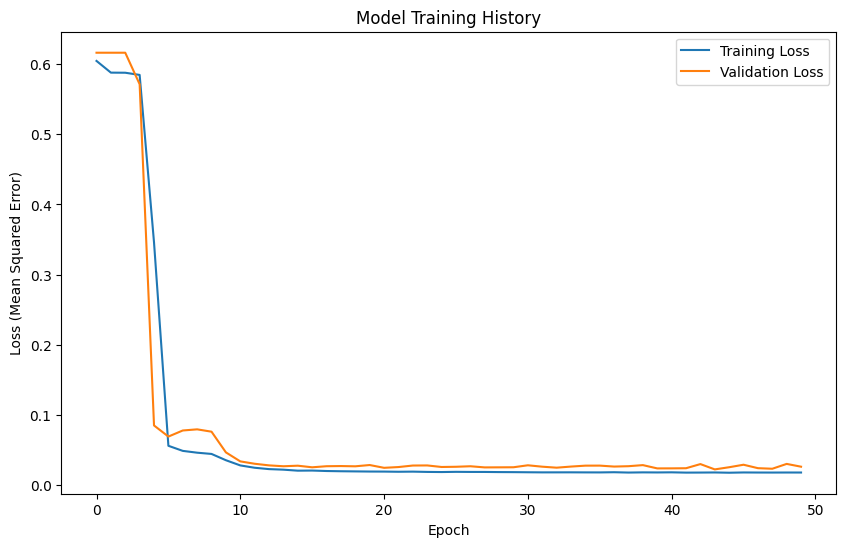

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.show()

## Comprehensive ANN Evaluation
Calculate additional evaluation metrics (MAE, R²) and create a scatter plot comparing actual vs predicted RUL with a perfect prediction line to visualize model performance.

--- Comprehensive Model Evaluation Metrics ---
Root Mean Squared Error (RMSE): 20.30
Mean Absolute Error (MAE): 16.42
R-squared (R²) Score: 0.743


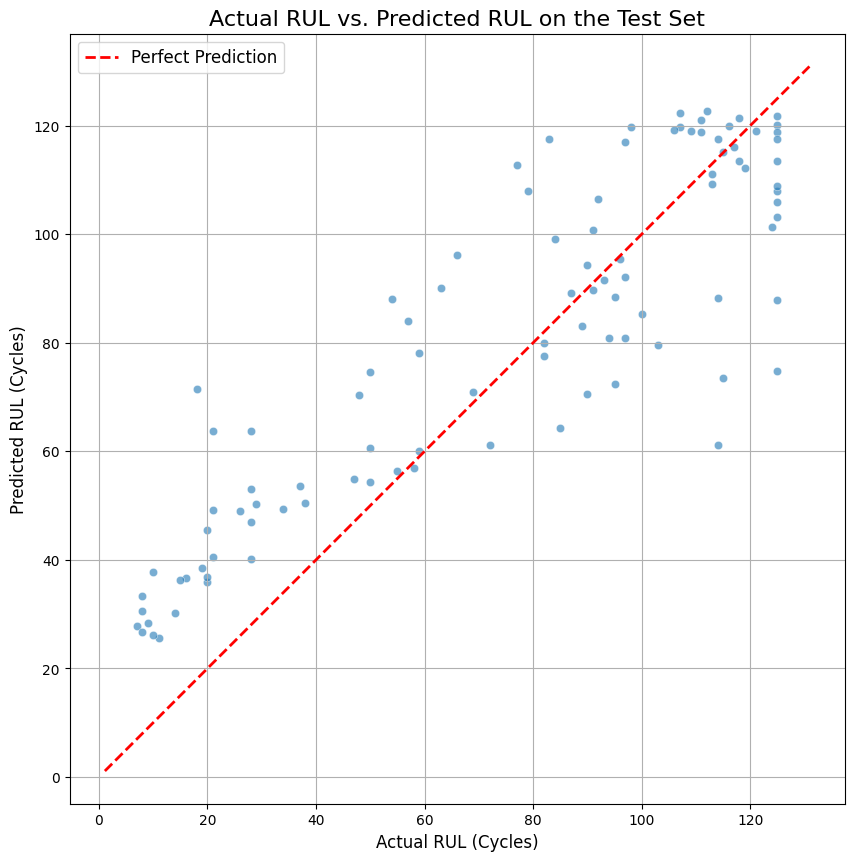

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score

# --- 1. Calculate the Core Numerical Metrics ---

# We already have RMSE, let's just recall it
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test_actual, y_pred)

# Calculate R-squared (R2) Score
r2 = r2_score(y_test_actual, y_pred)

print("--- Comprehensive Model Evaluation Metrics ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R²) Score: {r2:.3f}")


# --- 2. Create a Visual Evaluation Plot ---

# Create a scatter plot of the actual vs. predicted values
plt.figure(figsize=(10, 10))
sns.scatterplot(x=y_test_actual.flatten(), y=y_pred.flatten(), alpha=0.6)

# Add a "perfect prediction" line (y=x)
# We find the min and max of all values to set the line's limits
lims = [min(plt.gca().get_xlim()[0], plt.gca().get_ylim()[0]),
        max(plt.gca().get_xlim()[1], plt.gca().get_ylim()[1])]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')

plt.title('Actual RUL vs. Predicted RUL on the Test Set', fontsize=16)
plt.xlabel('Actual RUL (Cycles)', fontsize=12)
plt.ylabel('Predicted RUL (Cycles)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.axis('equal') # Ensures the x and y axes have the same scale
plt.show()

## Build and Train LSTM Model
Create a Long Short-Term Memory (LSTM) network with 2 LSTM layers (64, 32 units) and dropout. Train on sequence data to capture temporal dependencies for better RUL prediction.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# --- 1. Build the LSTM Architecture ---
lstm_model = Sequential()

# We need the input_shape just like with the TCN
lstm_model.add(LSTM(64, return_sequences=True, input_shape=(sequence_length, num_features)))
lstm_model.add(Dropout(0.2)) # Adding dropout for robustness
lstm_model.add(LSTM(32, return_sequences=False)) # This layer outputs a single summary
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(1, activation='relu')) # Final prediction layer

# --- 2. Compile the Model ---
optimizer = Adam(learning_rate=0.001)
lstm_model.compile(optimizer=optimizer, loss='mean_squared_error')

lstm_model.summary()

# --- 3. Train the Model ---
# We'll use the EXACT same data as the TCN for a fair fight
lstm_history = lstm_model.fit(X_TCN_train, y_TCN_train, epochs=50, batch_size=32, validation_split=0.2)

# --- 4. Evaluate the Model ---
# Predict in scaled format
y_pred_scaled_lstm = lstm_model.predict(X_TCN_test)

# Inverse transform back to real RUL values
y_pred_lstm = y_scaler.inverse_transform(y_pred_scaled_lstm)
y_test_actual_lstm = y_scaler.inverse_transform(y_TCN_test) # This is the same as y_test_actual_tcn

# Calculate metrics
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual_lstm, y_pred_lstm))
mae_lstm = mean_absolute_error(y_test_actual_lstm, y_pred_lstm)
r2_lstm = r2_score(y_test_actual_lstm, y_pred_lstm)

print("\n\n--- LSTM Model Evaluation Metrics ---")
print(f"Root Mean Squared Error (RMSE): {rmse_lstm:.2f}")
print(f"Mean Absolute Error (MAE): {mae_lstm:.2f}")
print(f"R-squared (R²) Score: {r2_lstm:.3f}")

c:\Users\ANISH\Desktop\Flight_management_model_training\ml_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 64)         │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,697 (131.63 KB)

 Trainable params: 33,697 (131.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - loss: 0.0361 - val_loss: 0.0171
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: 0.0188 - val_loss: 0.0135
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - loss: 0.0159 - val_loss: 0.0132
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - loss: 0.0138 - val_loss: 0.0150
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - loss: 0.0129 - val_loss: 0.0130
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - loss: 0.0126 - val_loss: 0.0162
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - loss: 0.0121 - val_loss: 0.0132
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - loss: 0.0115 - val_loss: 0.0132
Epoch 9/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - loss: 0.0109 - val_loss: 0.0113
Epoch 10/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - loss: 0.0106 - val_loss: 0.0134
Epoch 11/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - loss: 0.0103 - val_loss: 0.0117
Epoch 12/50
391/391 ━━━━━━━━━━

## Compare Model Performance
Create a summary table comparing all three models (ANN, LSTM, XGBoost) across key metrics (RMSE, MAE, R²) and identify the best performing model.

In [ ]:
print("\n\n--- THE ULTIMATE MODEL SHOWDOWN ---")

# Create a dictionary of all our results
results = {
    'Model': [
        'Artificial Neural Network (ANN)', 
        'Long Short-Term Memory (LSTM)',
        'XGBoost'
    ],
    'RMSE': [rmse, rmse_lstm, rmse_xgb],
    'MAE': [mae, mae_lstm, mae_xgb],
    'R-squared (R²)': [r2, r2_lstm, r2_xgb]
}

# Create a Pandas DataFrame for a beautiful table
results_df = pd.DataFrame(results)

# Set the 'Model' column as the index and sort by the best RMSE
results_df.set_index('Model', inplace=True)
results_df.sort_values(by='RMSE', inplace=True)

print(results_df.round(3))

# Print the champion
print(f"\n\nBest Result: {results_df.index[0]}")



--- THE ULTIMATE MODEL SHOWDOWN ---
                                   RMSE     MAE  R-squared (R²)
Model                                                          
Long Short-Term Memory (LSTM)    15.213  11.570           0.856
XGBoost                          18.023  13.656           0.798
Artificial Neural Network (ANN)  20.304  16.416           0.743


Best Result: Long Short-Term Memory (LSTM)


## Visual Model Comparison
Generate comparative visualizations: validation loss curves for deep learning models and scatter plots showing actual vs predicted RUL for both ANN and LSTM models.

--- Generating Final Comparative Visuals ---


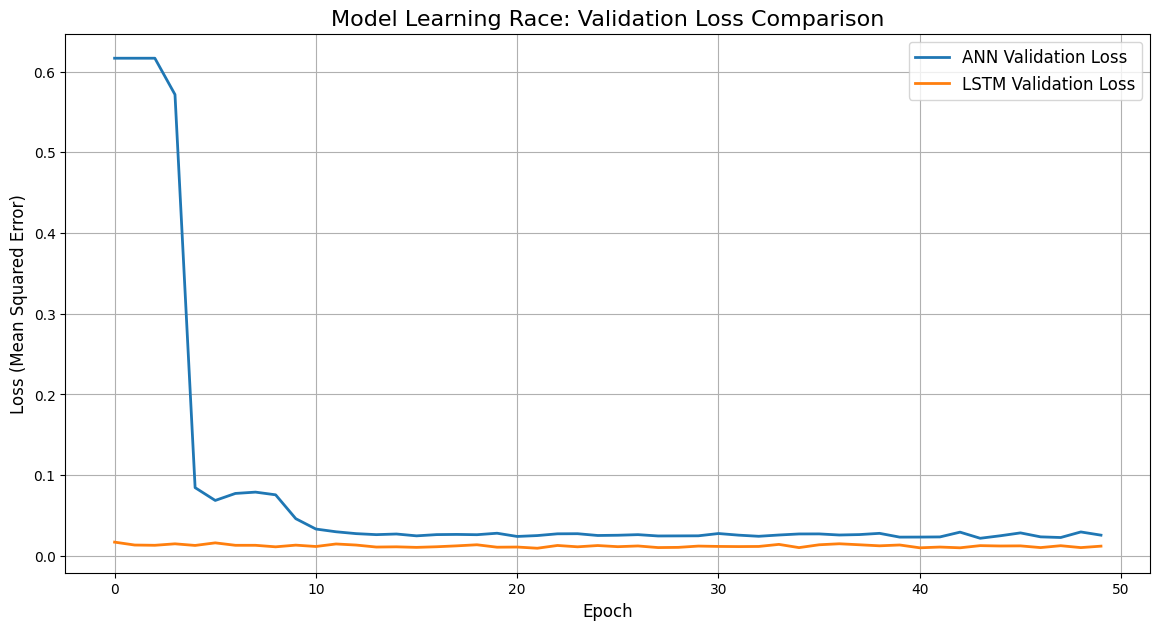

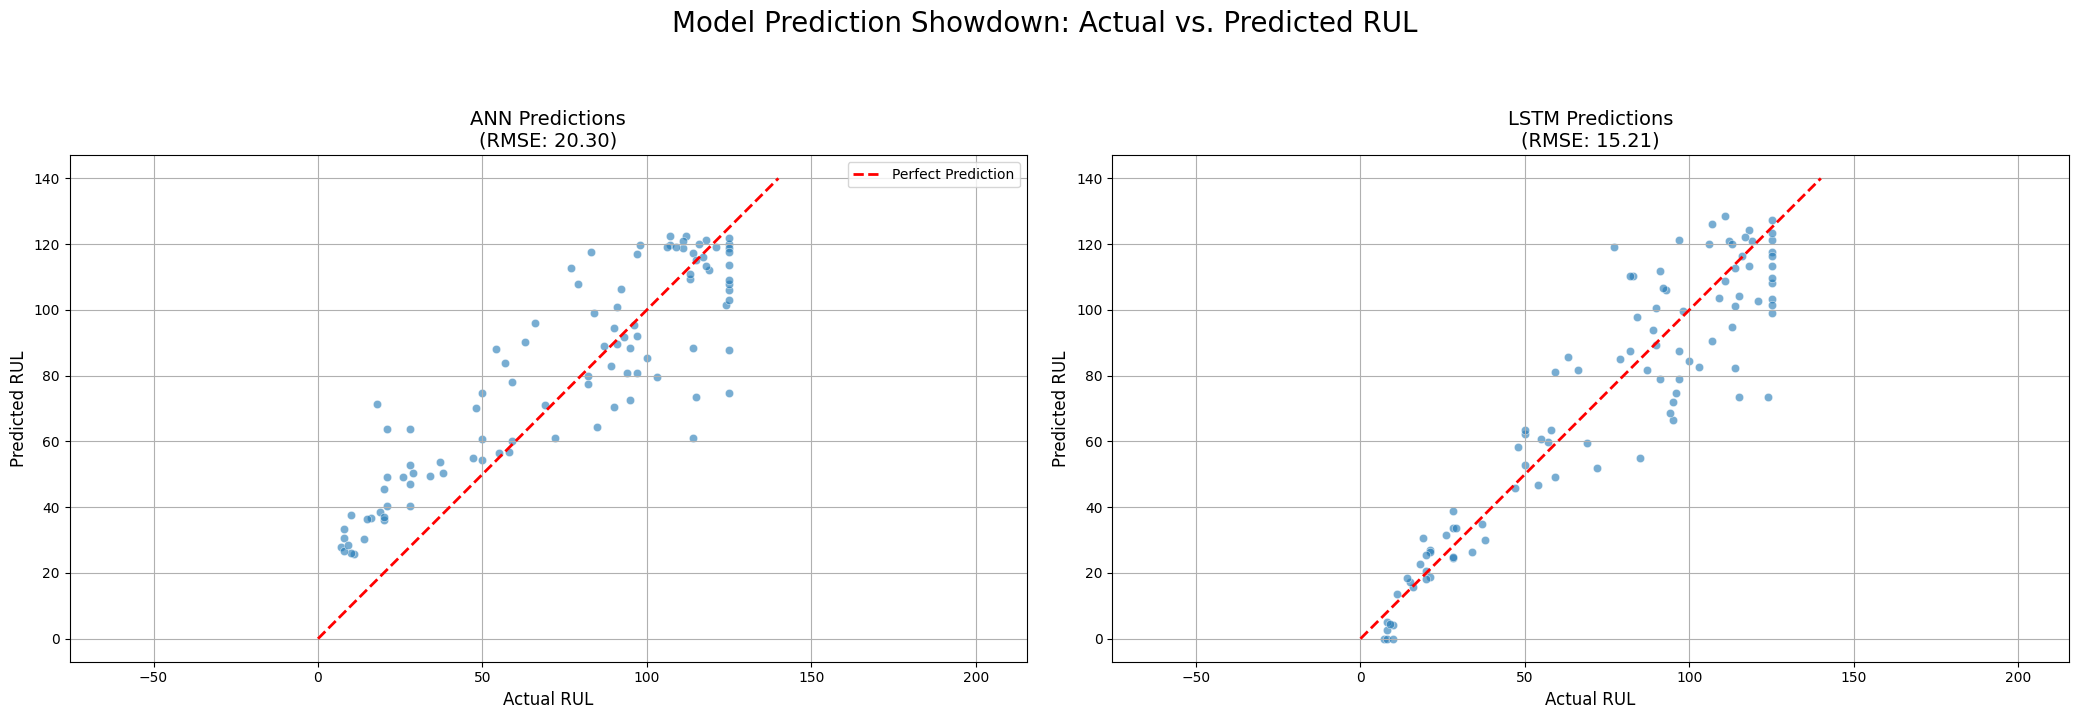

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Generating Final Comparative Visuals ---")

# --- 1. The Learning Race (Validation Loss Comparison) ---
plt.figure(figsize=(14, 7))
plt.plot(history.history['val_loss'], label='ANN Validation Loss', linewidth=2)
plt.plot(lstm_history.history['val_loss'], label='LSTM Validation Loss', linewidth=2)

plt.title('Model Learning Race: Validation Loss Comparison', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()


# --- 2. The Prediction Showdown (Actual vs. Predicted Comparison) ---
# --- THE FIX: Removed sharex=True and sharey=True ---
fig, axes = plt.subplots(1, 2, figsize=(21, 7))
fig.suptitle('Model Prediction Showdown: Actual vs. Predicted RUL', fontsize=20, y=1.02)

# ANN Subplot
sns.scatterplot(ax=axes[0], x=y_test_actual.flatten(), y=y_pred.flatten(), alpha=0.6)
axes[0].set_title(f'ANN Predictions\n(RMSE: {rmse:.2f})', fontsize=14)
axes[0].set_xlabel('Actual RUL', fontsize=12)
axes[0].set_ylabel('Predicted RUL', fontsize=12) # Kept y-label
axes[0].grid(True)
axes[0].plot([0, 140], [0, 140], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].axis('equal')
axes[0].legend() # Added legend to first plot


# LSTM Subplot
sns.scatterplot(ax=axes[1], x=y_test_actual_lstm.flatten(), y=y_pred_lstm.flatten(), alpha=0.6)
axes[1].set_title(f'LSTM Predictions\n(RMSE: {rmse_lstm:.2f})', fontsize=14)
axes[1].set_xlabel('Actual RUL', fontsize=12)
axes[1].set_ylabel('Predicted RUL', fontsize=12) # --- THE FIX: Added y-label back ---
axes[1].grid(True)
axes[1].plot([0, 140], [0, 140], 'r--', linewidth=2)
axes[1].axis('equal')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Build and Train XGBoost Model
Create an XGBoost gradient boosting regressor with 1000 trees. Train on 2D feature data (not sequences) as an ensemble learning approach to RUL prediction.

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("--- Starting XGBoost Model Training ---")

# --- 1. Define the XGBoost Model ---
# We instantiate the model with some common starting parameters.
# n_estimators is the number of trees in the forest.
# max_depth is how deep each tree can go.
# learning_rate is how much each new tree corrects the previous ones.
xgboost_model = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.05,
    n_jobs=-1,  # Use all available CPU cores
    random_state=42 # for reproducibility
)

# --- 2. Train the Model ---
# IMPORTANT: We use the 2D data prepared for the ANN, NOT the 3D sequence data.
# The 'y' data for the ANN was already scaled, so we will use it directly.
# However, y_train must be a 1D array for XGBoost. .ravel() flattens it.
xgboost_model.fit(X_train, y_train.ravel())

print("\nXGBoost training complete.")

# --- 3. Evaluate the Model ---
# Predict on the scaled X_test from the ANN prep
y_pred_scaled_xgb = xgboost_model.predict(X_test)

# Inverse transform the predictions using our trained y_scaler
y_pred_xgb = y_scaler.inverse_transform(y_pred_scaled_xgb.reshape(-1, 1))
# The y_test_actual is the same as we've used for all models
y_test_actual_xgb = y_scaler.inverse_transform(y_test)

# Calculate metrics
rmse_xgb = np.sqrt(mean_squared_error(y_test_actual_xgb, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test_actual_xgb, y_pred_xgb)
r2_xgb = r2_score(y_test_actual_xgb, y_pred_xgb)


print("\n--- XGBoost Model Evaluation Metrics ---")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.2f}")
print(f"Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"R-squared (R²) Score: {r2_xgb:.3f}")

--- Starting XGBoost Model Training ---

XGBoost training complete.

--- XGBoost Model Evaluation Metrics ---
Root Mean Squared Error (RMSE): 18.02
Mean Absolute Error (MAE): 13.66
R-squared (R²) Score: 0.798


## Final Visual Comparison (All Models)
Generate comprehensive visualizations comparing all three models: validation loss for deep learning models and side-by-side scatter plots showing prediction accuracy.



--- Generating Final 4-Model Comparative Visuals ---


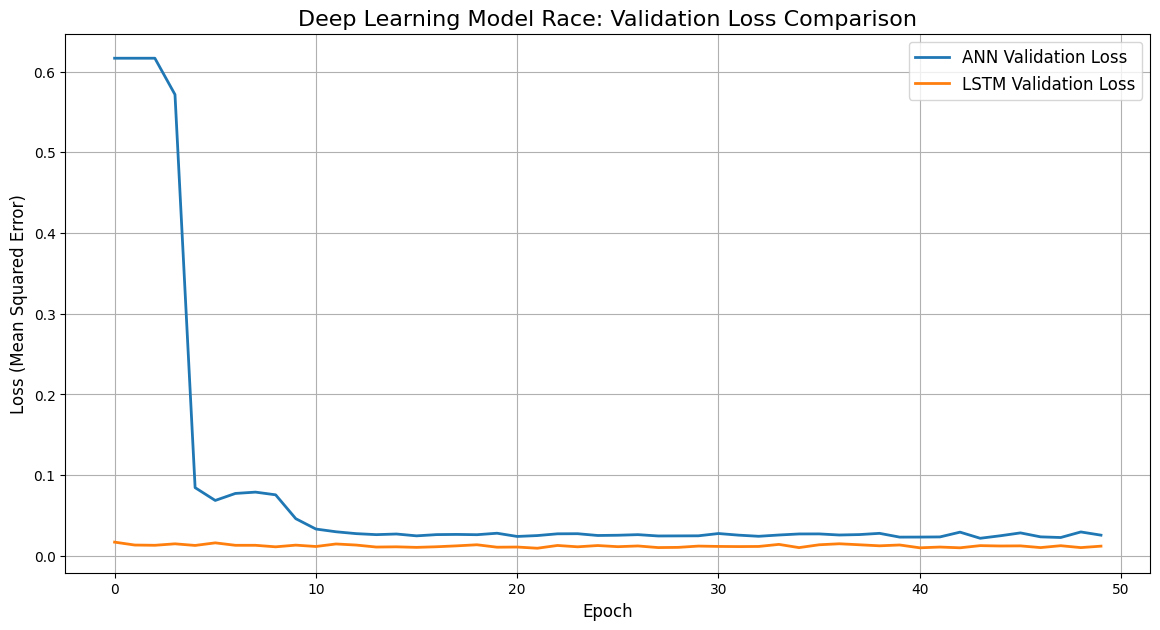

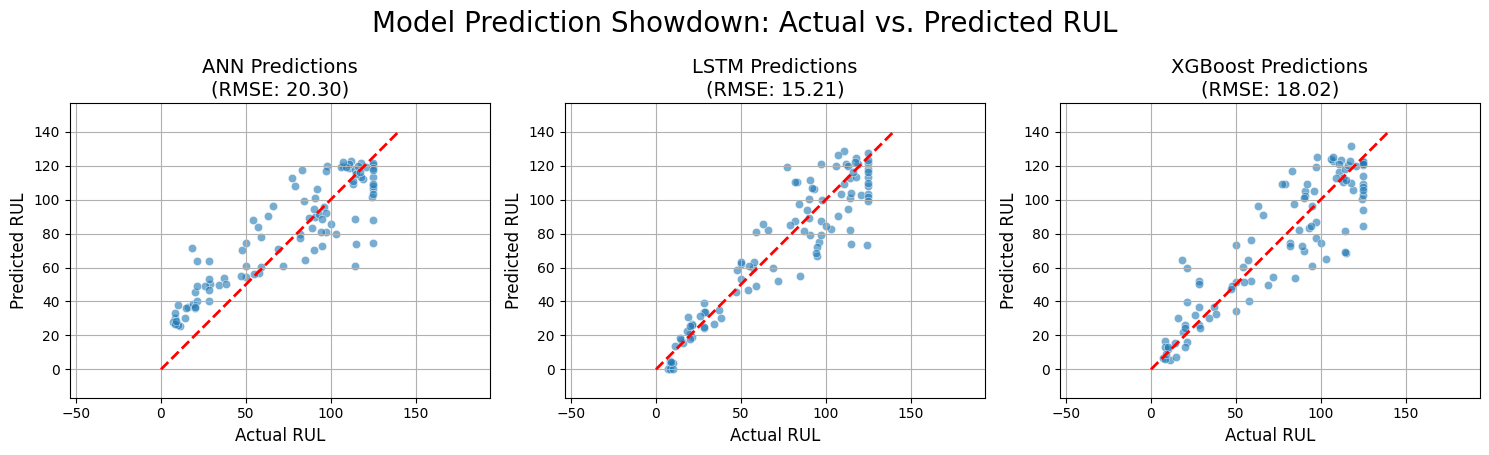

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n\n--- Generating Final 3-Model Comparative Visuals ---")

# --- 1. The Learning Race (Validation Loss Comparison for DL Models) ---
plt.figure(figsize=(14, 7))
plt.plot(history.history['val_loss'], label='ANN Validation Loss', linewidth=2)
plt.plot(lstm_history.history['val_loss'], label='LSTM Validation Loss', linewidth=2)
plt.title('Deep Learning Model Race: Validation Loss Comparison', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# --- 2. The Prediction Showdown ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Prediction Showdown: Actual vs. Predicted RUL', fontsize=20, y=0.93)

# Define models and their results for easier looping
model_data = {
    'ANN': (y_pred, y_test_actual, rmse),
    'LSTM': (y_pred_lstm, y_test_actual_lstm, rmse_lstm),
    'XGBoost': (y_pred_xgb, y_test_actual_xgb, rmse_xgb)
}

# Flatten axes for easy iteration
ax_flat = axes.flatten()

for i, (model_name, (y_p, y_t, r)) in enumerate(model_data.items()):
    ax = ax_flat[i]
    sns.scatterplot(ax=ax, x=y_t.flatten(), y=y_p.flatten(), alpha=0.6)
    ax.set_title(f'{model_name} Predictions\n(RMSE: {r:.2f})', fontsize=14)
    ax.set_xlabel('Actual RUL', fontsize=12)
    ax.set_ylabel('Predicted RUL', fontsize=12)
    ax.grid(True)
    # Add the "perfect prediction" line
    ax.plot([0, 140], [0, 140], 'r--', linewidth=2)
    ax.axis('equal') # Important for a fair visual comparison

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Save Model Artifacts (Commented)
Code to save the LSTM model and scalers for deployment. Currently commented out - uncomment to save the trained model and preprocessing objects.

In [ ]:
# import os
# import joblib

# # --- Define the directory to save artifacts ---
# artifact_path = './model_artifacts'
# os.makedirs(artifact_path, exist_ok=True) # Create the directory if it doesn't exist

# # --- 1. Save the Champion LSTM Model ---
# # We use the HDF5 format (.h5) to save a Keras model, which is the standard way.
# model_file_path = os.path.join(artifact_path, 'lstm_model.h5')
# lstm_model.save(model_file_path)

# print(f"LSTM model saved successfully to: {model_file_path}")


# # --- 2. Save the Input Scaler (for X features) ---
# # We use joblib, which is efficient for saving scikit-learn objects.
# scaler_file_path = os.path.join(artifact_path, 'input_scaler.joblib')
# joblib.dump(scaler, scaler_file_path)

# print(f"Input scaler saved successfully to: {scaler_file_path}")


# # --- 3. Save the Output Scaler (for y/RUL) ---
# y_scaler_file_path = os.path.join(artifact_path, 'output_scaler.joblib')
# joblib.dump(y_scaler, y_scaler_file_path)

# print(f"Output scaler saved successfully to: {y_scaler_file_path}")

# Cell to define advanced evaluation functions

In [ ]:
def analyze_error_bias(y_true, y_pred):
    """
    Analyzes the model's bias towards early or late predictions.
    - Early prediction (Conservative): Predicted RUL < Actual RUL.
    - Late prediction (Risky): Predicted RUL > Actual RUL.
    """
    errors = y_pred.flatten() - y_true.flatten()
    
    early_predictions = errors[errors < 0]
    late_predictions = errors[errors > 0]
    
    bias_metrics = {
        'Prediction Bias': 'Early' if np.mean(errors) < 0 else 'Late',
        'Count Early': len(early_predictions),
        'Count Late': len(late_predictions),
        'Avg. Early Error (cycles)': np.mean(np.abs(early_predictions)) if len(early_predictions) > 0 else 0,
        'Avg. Late Error (cycles)': np.mean(late_predictions) if len(late_predictions) > 0 else 0
    }
    return bias_metrics

def analyze_performance_by_horizon(y_true, y_pred):
    """
    Analyzes model RMSE across different RUL horizons (quartiles).
    """
    # Create a DataFrame for easy manipulation
    df = pd.DataFrame({'Actual_RUL': y_true.flatten(), 'Predicted_RUL': y_pred.flatten()})
    
    # Create RUL quartiles (horizons)
    df['RUL_Horizon'] = pd.qcut(df['Actual_RUL'], q=4, labels=['Imminent (0-25%)', 'Near-Term (25-50%)', 'Mid-Term (50-75%)', 'Long-Term (75-100%)'])
    
    # Calculate RMSE for each horizon
    horizon_performance = df.groupby('RUL_Horizon').apply(
        lambda x: np.sqrt(mean_squared_error(x['Actual_RUL'], x['Predicted_RUL']))
    )
    return horizon_performance

def plot_residuals(model_name, y_true, y_pred):
    """
    Creates a residual plot to visually inspect error distribution.
    A good residual plot should show random, uniform scatter around the y=0 line.
    """
    residuals = y_true.flatten() - y_pred.flatten()
    
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_pred.flatten(), y=residuals, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title(f'Residual Plot for {model_name}', fontsize=16)
    plt.xlabel('Predicted RUL (Cycles)', fontsize=12)
    plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
    plt.grid(True)
    plt.show()

## Extended Evaluation Metrics
Define a comprehensive evaluation function that calculates additional metrics (MAPE, Median AE, Max Error, Explained Variance) and generates a final comparison report for all three models.

More evaluation matrices 

In [ ]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score, explained_variance_score, max_error, median_absolute_error

def mean_absolute_percentage_error(y_true, y_pred): 
    # A small constant is added to avoid division by zero
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

def evaluate_model(model_name, y_true, y_pred):
    """Calculates all metrics for a given model and returns a dictionary."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true.flatten(), y_pred.flatten())
    medae = median_absolute_error(y_true, y_pred)
    max_err = max_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    explained_variance = explained_variance_score(y_true, y_pred)
    
    metrics = {
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'Median AE': medae,
        'MAPE (%)': mape,
        'Max Error': max_err,
        'R-squared (R²)': r2,
        'Explained Variance': explained_variance
    }
    return metrics

# --- Generate evaluations for all three successful models ---
# Note: Ensure the prediction and true value variables are correct for each model
ann_metrics = evaluate_model('ANN', y_test_actual, y_pred)
lstm_metrics = evaluate_model('LSTM', y_test_actual_lstm, y_pred_lstm)
xgb_metrics = evaluate_model('XGBoost', y_test_actual_xgb, y_pred_xgb)

# --- Consolidate results into a final DataFrame ---
final_report_df = pd.DataFrame([lstm_metrics, ann_metrics, xgb_metrics])
final_report_df.set_index('Model', inplace=True)
final_report_df.sort_values(by='RMSE', inplace=True) # Sort by our primary error metric

print("--- Final Comprehensive Model Evaluation Report ---")
print(final_report_df.round(3))

--- Final Comprehensive Model Evaluation Report ---
           RMSE     MAE  Median AE  MAPE (%)  Max Error  R-squared (R²)  \
Model                                                                     
LSTM     15.213  11.570      8.257    20.555     50.526           0.856   
XGBoost  18.023  13.656      9.660    25.983     46.322           0.798   
ANN      20.304  16.416     16.028    52.028     53.490           0.743   

         Explained Variance  
Model                        
LSTM                  0.858  
XGBoost               0.798  
ANN                   0.765  


## Sample Predictions Comparison (All Models)
Display sample predictions from all three models side by side to compare how each model predicts RUL for the same test engines.

In [ ]:
import pandas as pd

print("--- Sample Predictions Comparison: All Three Models ---\n")

# Create a comprehensive comparison dataframe
predictions_comparison = pd.DataFrame({
    'Actual_RUL': y_test_actual.flatten().astype(int),
    'ANN_Predicted': y_pred.flatten().astype(int),
    'LSTM_Predicted': y_pred_lstm.flatten().astype(int),
    'XGBoost_Predicted': y_pred_xgb.flatten().astype(int)
})

# Add error columns for each model (keeping decimals for errors)
predictions_comparison['ANN_Error'] = y_pred.flatten() - y_test_actual.flatten()
predictions_comparison['LSTM_Error'] = y_pred_lstm.flatten() - y_test_actual_lstm.flatten()
predictions_comparison['XGBoost_Error'] = y_pred_xgb.flatten() - y_test_actual_xgb.flatten()

# Set the unit_nr as index
predictions_comparison.index = test_df.groupby('unit_nr').last().index
predictions_comparison.index.name = 'Unit_Nr'

# Display the first 15 samples for better comparison
print("First 15 Test Engines - Predictions and Errors:")
print("="*120)
print(predictions_comparison.head(15).round(2))

print("\n\nLast 10 Test Engines - Predictions and Errors:")
print("="*120)
print(predictions_comparison.tail(10).round(2))

# Summary statistics
print("\n\n--- Summary Statistics Across All Predictions ---")
print("="*120)
summary_stats = predictions_comparison.describe().round(2)
print(summary_stats)

--- Sample Predictions Comparison: All Three Models ---

First 15 Test Engines - Predictions and Errors:
         Actual_RUL  ANN_Predicted  LSTM_Predicted  XGBoost_Predicted  \
Unit_Nr                                                                 
1               112            122             120                123   
2                98            119              99                125   
3                69             70              59                 49   
4                82             79              87                 74   
5                91             89              79                105   
6                93             91             106                 83   
7                91            100             111                101   
8                95             72              66                 60   
9               111            118             108                116   
10               96             95              74                104   
11               97

  ADVANCED MODEL EVALUATION - RESEARCH REPORT  
--- Deep Dive Analysis for: LSTM ---

1. Error Bias Analysis:
  Prediction Bias  Count Early  Count Late  Avg. Early Error (cycles)  Avg. Late Error (cycles)
0           Early           54          46                  12.574972                 10.390349


C:\Users\ANISH\AppData\Local\Temp\ipykernel_25608\134263624.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  horizon_performance = df.groupby('RUL_Horizon').apply(
C:\Users\ANISH\AppData\Local\Temp\ipykernel_25608\134263624.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  horizon_performance = df.groupby('RUL_Horizon').apply(



2. Performance by RUL Horizon (RMSE):
RUL_Horizon
Imminent (0-25%)        5.724
Near-Term (25-50%)     16.724
Mid-Term (50-75%)      16.107
Long-Term (75-100%)    18.810

3. Residual Plot:


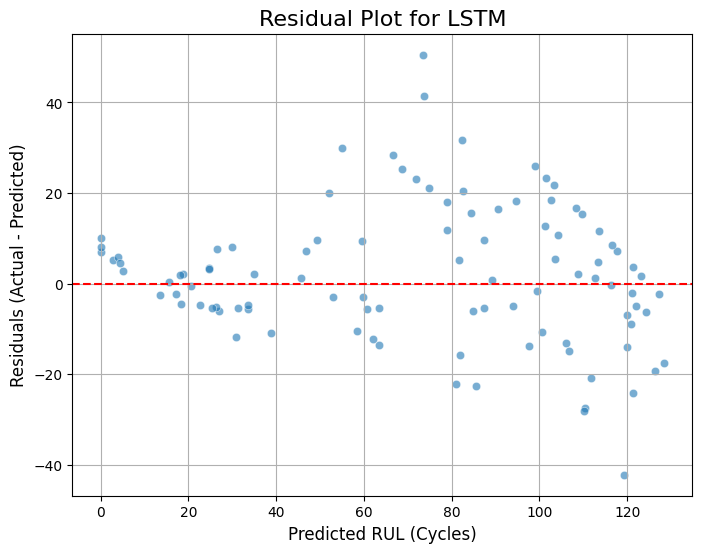


---------------------------------------------

--- Deep Dive Analysis for: ANN ---

1. Error Bias Analysis:
  Prediction Bias  Count Early  Count Late  Avg. Early Error (cycles)  Avg. Late Error (cycles)
0            Late           38          62                  13.846579                 17.991163

2. Performance by RUL Horizon (RMSE):
RUL_Horizon
Imminent (0-25%)       24.924
Near-Term (25-50%)     19.988
Mid-Term (50-75%)      13.171
Long-Term (75-100%)    21.325

3. Residual Plot:


C:\Users\ANISH\AppData\Local\Temp\ipykernel_25608\134263624.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  horizon_performance = df.groupby('RUL_Horizon').apply(
C:\Users\ANISH\AppData\Local\Temp\ipykernel_25608\134263624.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  horizon_performance = df.groupby('RUL_Horizon').apply(


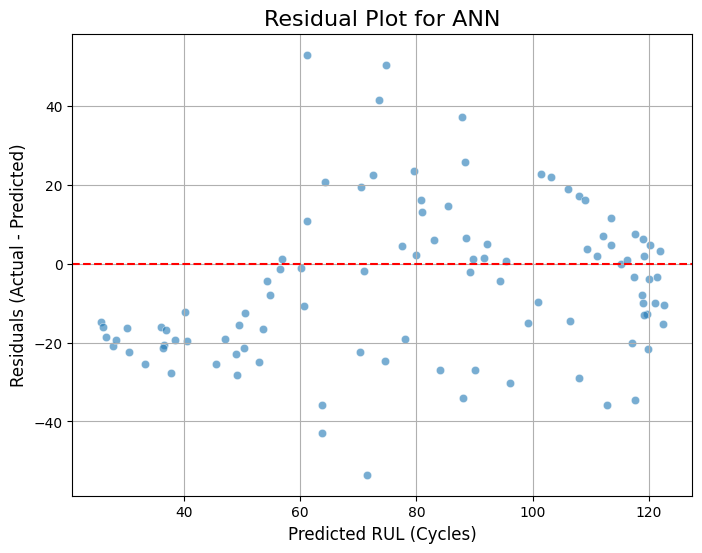


---------------------------------------------

--- Deep Dive Analysis for: XGBoost ---

1. Error Bias Analysis:
  Prediction Bias  Count Early  Count Late  Avg. Early Error (cycles)  Avg. Late Error (cycles)
0           Early           51          49                  13.855796                 13.447995

2. Performance by RUL Horizon (RMSE):
RUL_Horizon
Imminent (0-25%)       15.181
Near-Term (25-50%)     18.304
Mid-Term (50-75%)      17.743
Long-Term (75-100%)    20.471

3. Residual Plot:


C:\Users\ANISH\AppData\Local\Temp\ipykernel_25608\134263624.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  horizon_performance = df.groupby('RUL_Horizon').apply(
C:\Users\ANISH\AppData\Local\Temp\ipykernel_25608\134263624.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  horizon_performance = df.groupby('RUL_Horizon').apply(


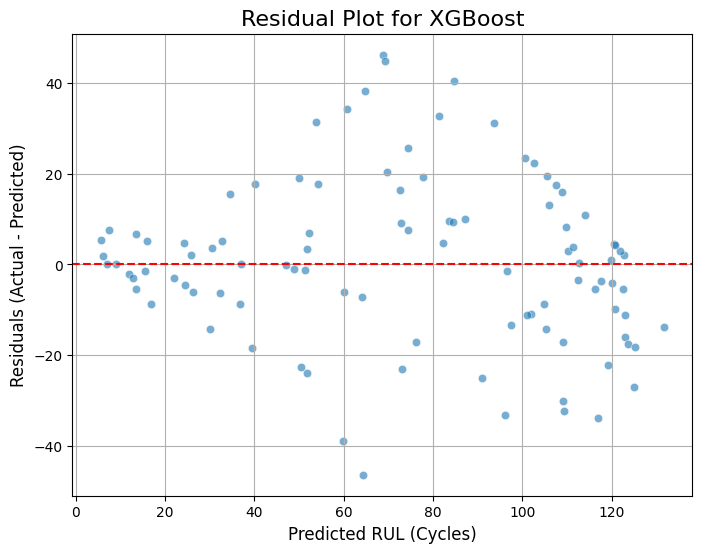


---------------------------------------------



In [ ]:
# --- Select the models to analyze ---
models_to_analyze = {
    'LSTM': (y_test_actual_lstm, y_pred_lstm),
    'ANN': (y_test_actual, y_pred),
    'XGBoost': (y_test_actual_xgb, y_pred_xgb)
}

print("  ADVANCED MODEL EVALUATION - RESEARCH REPORT  ")


for model_name, (y_true, y_pred) in models_to_analyze.items():
    print(f"--- Deep Dive Analysis for: {model_name} ---")
    
    # 1. Error Bias Analysis
    bias_report = analyze_error_bias(y_true, y_pred)
    print("\n1. Error Bias Analysis:")
    bias_df = pd.DataFrame([bias_report])
    print(bias_df.to_string())

    # 2. Performance by RUL Horizon
    horizon_report = analyze_performance_by_horizon(y_true, y_pred)
    print("\n2. Performance by RUL Horizon (RMSE):")
    print(horizon_report.round(3).to_string())
    
    # 3. Residual Plot
    print("\n3. Residual Plot:")
    plot_residuals(model_name, y_true, y_pred)
    
    print("\n---------------------------------------------\n")